# Exploratory Data Analysis

**Abriliam Consulting** — Industrial Energy Management

Before building any models, we need to understand the shape and character of the data. This notebook examines the chiller plant dataset through summary statistics, time-series trends, and correlation analysis to surface anomalies and guide the diagnostic investigation.


In [ ]:
import matplotlib
matplotlib.use('Agg')
# Load the dataset generated in Notebook 01
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('chiller_plant_data.csv', index_col=0, parse_dates=True)
print(f'Loaded {len(df)} rows, columns: {list(df.columns)}')


In [ ]:
import numpy as np

def create_spline(x, y, num_points=300):
    """Create smooth interpolation for plotting (uses numpy interp)."""
    mask = np.isfinite(x) & np.isfinite(y)
    x_clean, y_clean = np.array(x)[mask], np.array(y)[mask]
    if len(x_clean) < 4:
        return x_clean, y_clean
    x_new = np.linspace(x_clean.min(), x_clean.max(), num_points)
    y_new = np.interp(x_new, x_clean, y_clean)
    return x_new, y_new
# Compute spline variables from df
time_numeric = (df.index - df.index[0]).total_seconds().values
time_spline, _ = create_spline(time_numeric, time_numeric)
_, cw_flow_spline = create_spline(time_numeric, df['cw_flow_m3h'].values)
_, kw_per_ton_spline = create_spline(time_numeric, df['kw_per_ton'].values)

In [ ]:
import numpy as np

def create_spline(x, y, num_points=300):
    """Create smooth interpolation for plotting (uses numpy interp)."""
    mask = np.isfinite(x) & np.isfinite(y)
    x_clean, y_clean = np.array(x)[mask], np.array(y)[mask]
    if len(x_clean) < 4:
        return x_clean, y_clean
    x_new = np.linspace(x_clean.min(), x_clean.max(), num_points)
    y_new = np.interp(x_new, x_clean, y_clean)
    return x_new, y_new
# Compute spline variables from df
time_numeric = (df.index - df.index[0]).total_seconds().values
time_spline, _ = create_spline(time_numeric, time_numeric)
_, cw_flow_spline = create_spline(time_numeric, df['cw_flow_m3h'].values)
_, kw_per_ton_spline = create_spline(time_numeric, df['kw_per_ton'].values)

In [3]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values in each column:")
print(missing_values)

# Summary statistics
summary_statistics = df.describe()
print("\nSummary statistics:")
print(summary_statistics)

Missing values in each column:
oat_C                   0
wb_C                    0
occ                     0
tons                    0
chw_sup_C               0
chw_ret_C               0
chw_dT_C                0
chw_flow_m3h            0
cw_sup_C                0
cw_ret_C                0
cw_dT_C                 0
cw_flow_m3h             0
approach_C              0
dp_kpa                  0
chiller_kw              0
tower_fan_kw            0
chw_pump_kw             0
cw_pump_kw              0
plant_kw                0
kw_per_ton              0
plant_kw_per_ton        0
tower_fan_kw_per_ton    0
pumping_kw_per_ton      0
dtype: int64

Summary statistics:
             oat_C         wb_C          occ         tons    chw_sup_C  \
count  1344.000000  1344.000000  1344.000000  1344.000000  1344.000000   
mean     21.971768    18.469857     0.437281   202.310180     6.497118   
std       5.537674     5.223145     0.236582    72.427236     0.199888   
min       9.528023     7.674085     0.003

### Data Quality Check

No missing values across all 23 columns — the dataset is complete. Key observations from the summary statistics:

- **Cooling load** ranges from 40 to 361 tons with a mean of 202 tons — typical part-load operation for a mid-size plant
- **CHW delta-T** averages 5.2°C but has a wide standard deviation (0.96°C), hinting at the low-delta-T issue
- **Plant kW/ton** ranges from 2.8 to 7.6 — the high end represents severely inefficient operation
- **Approach temperature** averages 4.7°C, which is reasonable, but the range (2.5–9.0°C) suggests degradation over time


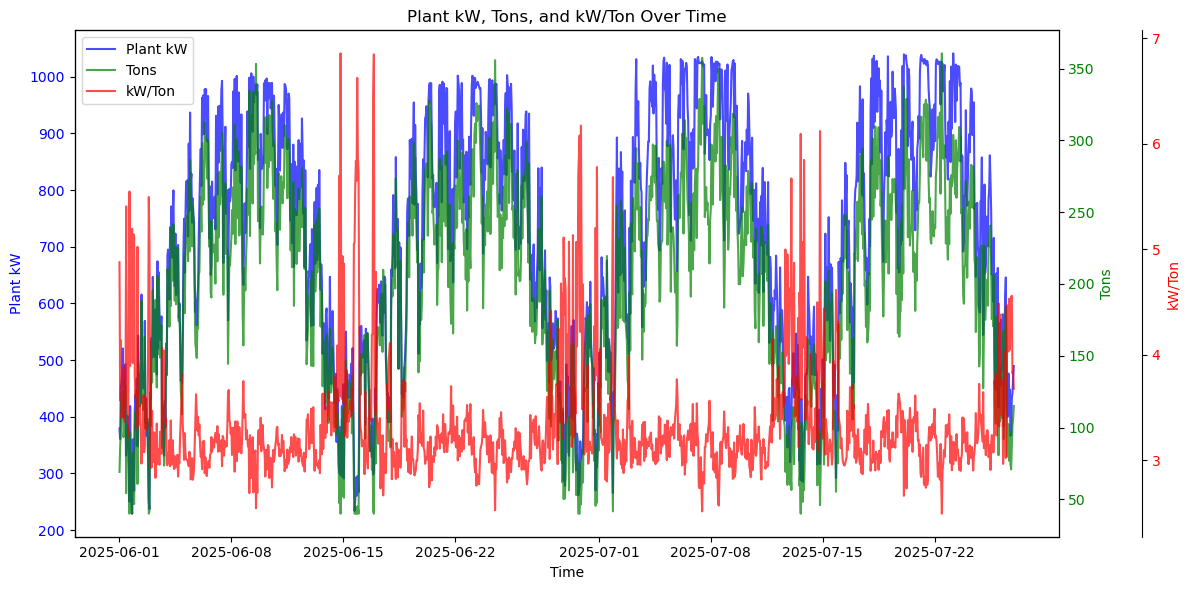

In [5]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot kW on the primary y-axis
ax1.plot(df.index, df['plant_kw'], label='Plant kW', color='blue', alpha=0.7)
ax1.set_xlabel('Time')
ax1.set_ylabel('Plant kW', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Add tons on the secondary y-axis
ax2 = ax1.twinx()
ax2.plot(df.index, df['tons'], label='Tons', color='green', alpha=0.7)
ax2.set_ylabel('Tons', color='green')
ax2.tick_params(axis='y', labelcolor='green')

# Add kW/ton on a third y-axis
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))  # Offset the third axis
ax3.plot(df.index, df['kw_per_ton'], label='kW/Ton', color='red', alpha=0.7)
ax3.set_ylabel('kW/Ton', color='red')
ax3.tick_params(axis='y', labelcolor='red')

# Add legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
ax1.legend(lines + lines2 + lines3, labels + labels2 + labels3, loc='upper left')

plt.title('Plant kW, Tons, and kW/Ton Over Time')
plt.tight_layout()
plt.close("all")

### Time-Series Overview

The triple-axis time-series plot reveals several important patterns:

- **Plant kW** (blue) and **Tons** (green) follow expected daily and weekly cycles — higher during occupied weekday hours, lower overnight and weekends
- **kW/Ton** (red) spikes during low-load periods, particularly overnight. This is characteristic of a plant with significant fixed power consumption (pump minimums, tower fan base load) that can't scale down proportionally at low loads
- The relationship between kW and Tons appears to shift after early July — the same cooling load requires more power


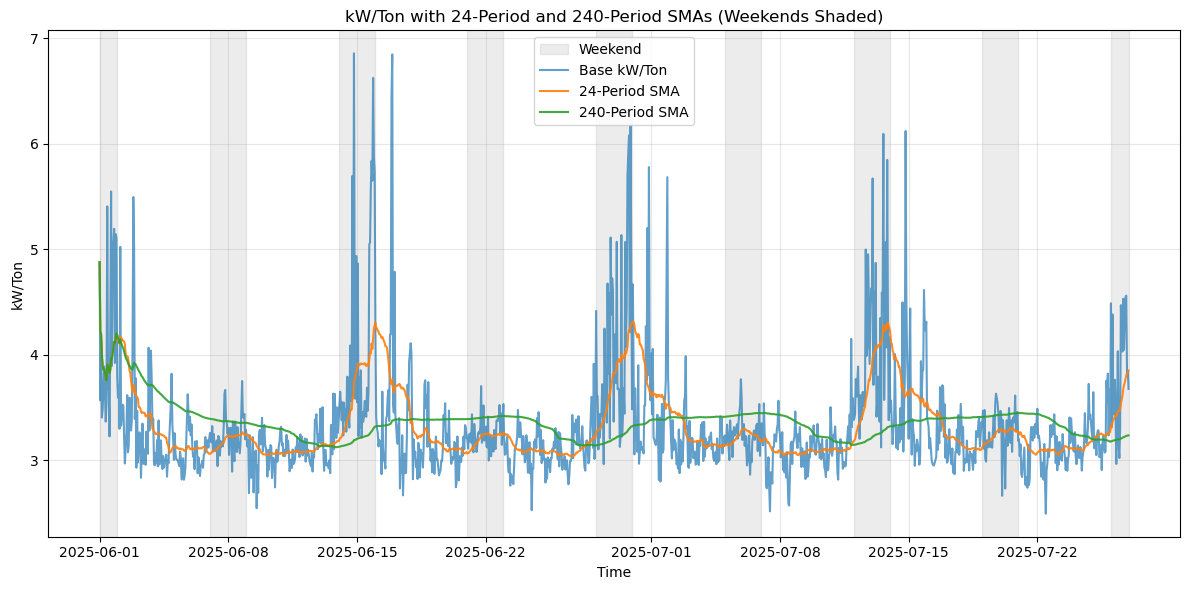

In [11]:
import matplotlib
matplotlib.use('Agg')
import pandas as pd
import matplotlib.pyplot as plt

# Ensure datetime index
df = df.copy()
df.index = pd.to_datetime(df.index)

# Rolling SMAs
df['kw_per_ton_24_sma']  = df['kw_per_ton'].rolling(window=24, min_periods=1).mean()
df['kw_per_ton_240_sma'] = df['kw_per_ton'].rolling(window=240, min_periods=1).mean()

plt.figure(figsize=(12, 6))

# --- Weekend shading (make mask a pandas Series so shift works) ---
weekend = pd.Series(df.index.weekday >= 5, index=df.index)  # True on Sat/Sun

# Weekend start = True now, False previous
weekend_starts = df.index[weekend & ~weekend.shift(1, fill_value=False)]

# Weekend end = True now, False next (end timestamp of last weekend sample)
weekend_ends = df.index[weekend & ~weekend.shift(-1, fill_value=False)]

# Shade weekends
for i, (start, end) in enumerate(zip(weekend_starts, weekend_ends)):
    plt.axvspan(start, end, alpha=0.15, color='gray', label='Weekend' if i == 0 else None)

# Plot series
plt.plot(df.index, df['kw_per_ton'],          label='Base kW/Ton', alpha=0.7)
plt.plot(df.index, df['kw_per_ton_24_sma'],   label='24-Period SMA', alpha=0.9)
plt.plot(df.index, df['kw_per_ton_240_sma'],  label='240-Period SMA', alpha=0.9)

plt.title('kW/Ton with 24-Period and 240-Period SMAs (Weekends Shaded)')
plt.xlabel('Time')
plt.ylabel('kW/Ton')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.close("all")


### Moving Average Analysis

The 240-hour (10-day) simple moving average of kW/ton shows a clear upward drift starting in early July. This long-term trend confirms that something changed in plant operations — the plant is becoming less efficient even after smoothing out weather and load variability. Weekend periods (shaded) consistently show higher kW/ton due to the part-load penalty.


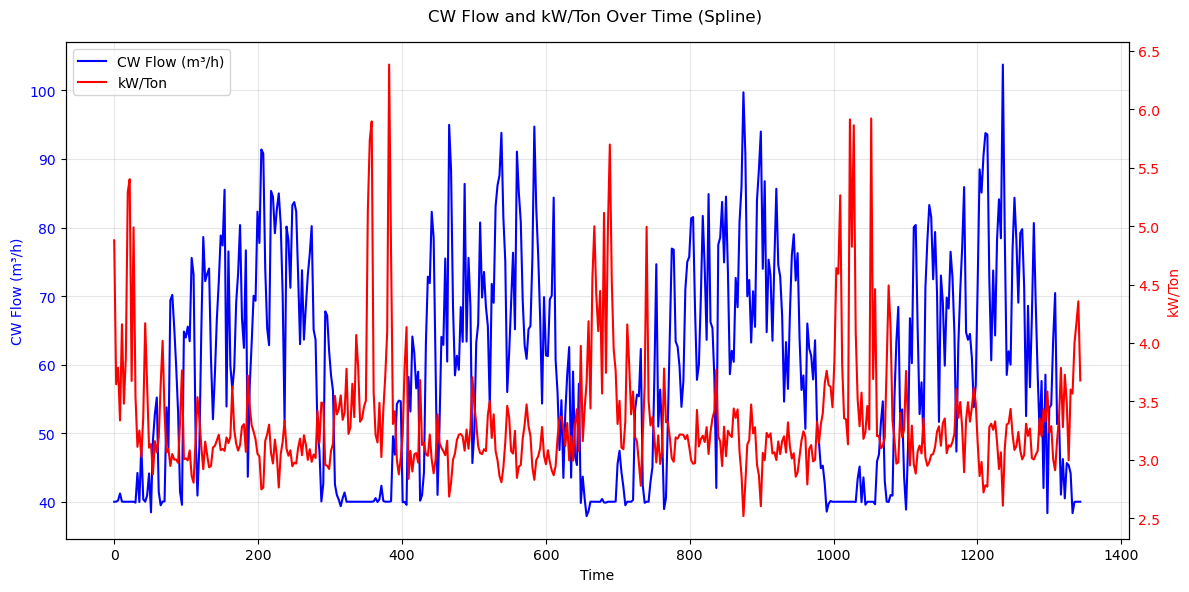

In [18]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot CW flow on the primary y-axis
ax1.plot(time_spline, cw_flow_spline, label='CW Flow (m³/h)', color='blue')
ax1.set_xlabel('Time')
ax1.set_ylabel('CW Flow (m³/h)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Add kW/Ton on the secondary y-axis
ax2 = ax1.twinx()
ax2.plot(time_spline, kw_per_ton_spline, label='kW/Ton', color='red')
ax2.set_ylabel('kW/Ton', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Add title and legends
fig.suptitle('CW Flow and kW/Ton Over Time (Spline)')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.grid(alpha=0.3)
plt.tight_layout()
plt.close("all")

### Condenser Water Flow vs Efficiency

Condenser water flow and chiller efficiency are correlated — higher CW flow corresponds to higher loads and generally better kW/ton. The spline smoothing helps visualize the underlying trend without hourly noise. Both metrics show seasonal variation driven by outdoor conditions.


In [19]:
df.describe()

,oat_C,wb_C,occ,tons,chw_sup_C,chw_ret_C,chw_dT_C,chw_flow_m3h,cw_sup_C,cw_ret_C,...,cw_pump_kw,plant_kw,kw_per_ton,plant_kw_per_ton,tower_fan_kw_per_ton,pumping_kw_per_ton,kw_per_ton_15_sma,kw_per_ton_5_sma,kw_per_ton_24_sma,kw_per_ton_240_sma
count,1344.000000,1344.000000,1344.000000,1344.000000,1344.000000,1344.000000,1344.000000,1344.000000,1344.000000,1344.000000,...,1344.000000,1344.000000,1344.000000,1344.000000,1344.000000,1344.000000,1330.000000,1340.000000,1344.000000,1344.000000
mean,21.971768,18.469857,0.437281,202.310180,6.497118,11.698814,5.201697,123.286156,23.223926,27.521415,...,8.599194,722.870498,3.331991,3.740465,0.147641,0.260833,3.325178,3.329938,3.332719,3.367520
std,5.537674,5.223145,0.236582,72.427236,0.199888,0.977320,0.958199,53.350509,5.367137,5.622375,...,2.602534,211.832906,0.534258,0.623603,0.087723,0.064297,0.351797,0.436612,0.325486,0.173593
min,9.528023,7.674085,0.003374,40.000000,5.814391,9.626562,3.216000,18.801814,10.437609,14.091599,...,5.000000,228.816352,2.495624,2.775560,0.032155,0.143180,2.936343,2.760202,3.037449,3.125798
25%,17.243689,13.835159,0.298208,147.201633,6.359207,10.794124,4.256318,82.148731,18.504226,22.558544,...,6.388679,549.172073,3.046748,3.399471,0.090503,0.203011,3.106304,3.074437,3.105068,3.246344
50%,22.019321,18.588505,0.368380,214.134704,6.508027,11.957734,5.557457,122.019542,23.301704,27.724563,...,8.381974,757.822436,3.191399,3.583410,0.121378,0.242365,3.195772,3.199272,3.197062,3.385068
75%,26.550146,23.203806,0.601501,257.748715,6.637654,12.561173,6.052536,158.086490,27.887926,32.345008,...,10.689970,899.344803,3.405071,3.836126,0.170387,0.317086,3.375653,3.407882,3.449104,3.413820
max,34.455590,29.209971,0.985438,360.631196,7.078945,13.841881,7.081364,312.989726,35.000361,40.469019,...,16.127471,1041.126945,6.857364,7.590985,0.633392,0.560377,4.729038,5.944731,4.878574,4.878574
